# Lab 3: Contextual Bandit – News Article Recommendation

**Name:** Aryan Gosain  
**Roll Number:** U20230108  

This notebook covers:
- Data preprocessing
- User classification model (Context detection)
- Contextual Bandit (Epsilon-Greedy, UCB, SoftMax)
- Recommendation Engine
- Evaluation & Reporting

## 5.1 Data Pre-processing

- Load user and article datasets  
- Clean data (handle missing values)  
- Apply feature encoding for classification

In [1]:
# importing libraries
import pandas as pd
import numpy as np

# loading the datasets
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")
news_articles = pd.read_csv("data/news_articles.csv")

# data shapes
print("train_users shape:", train_users.shape)
print("test_users shape:", test_users.shape)
print("news_articles shape:", news_articles.shape)

# checking for missing values
print("\nMissing values:")
print(train_users.isnull().sum())

train_users shape: (2000, 33)
test_users shape: (2000, 32)
news_articles shape: (209527, 6)

Missing values:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment

In [2]:
# removing duplicates
train_users = train_users.drop_duplicates()
test_users = test_users.drop_duplicates()
news_articles = news_articles.drop_duplicates()

# handling missing values 
# i saw that age has missing values, so filling with median
numeric_cols_list = train_users.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols_list:
    if col != "label":  
        median_val = train_users[col].median()
        train_users[col] = train_users[col].fillna(median_val)

for col in numeric_cols_list:
    if col in test_users.columns and col != "label":
        median_val = train_users[col].median()  # using train median
        test_users[col] = test_users[col].fillna(median_val)

# checking what columns we have
print("columns in train_users:", train_users.columns.tolist()[:5], "...")
print("\nmissing values after filling:", train_users.isnull().sum().sum())

columns in train_users: ['user_id', 'age', 'income', 'clicks', 'purchase_amount'] ...

missing values after filling: 0


In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# getting feature columns
feature_cols = []
for col in train_users.columns:
    if col != "user_id" and col != "label":
        feature_cols.append(col)

print("total feature columns:", len(feature_cols))

# separating numeric and categorical columns
numeric_cols = []
categorical_cols = []

for col in feature_cols:
    if train_users[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print("numeric columns:", len(numeric_cols))
print("categorical columns:", categorical_cols)

# preparing X and y
X_full = train_users[feature_cols].copy()
y_full = train_users["label"].copy()

# encoding labels 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_full)

print("\nlabel encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

# scaling  features
scaler = StandardScaler()
X_numeric = X_full[numeric_cols].copy()
X_numeric_scaled = scaler.fit_transform(X_numeric)
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_cols)

# one hot encoding 
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50)
X_categorical = X_full[categorical_cols].copy()
X_categorical_encoded = ohe.fit_transform(X_categorical)
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
X_categorical_df = pd.DataFrame(X_categorical_encoded, columns=cat_feature_names)

# combining everything
X_processed = pd.concat([X_numeric_scaled_df, X_categorical_df], axis=1)
print("\nfinal feature matrix shape:", X_processed.shape)

total feature columns: 31
numeric columns: 28
categorical columns: ['browser_version', 'region_code', 'subscriber']

label encoding:
user_1 -> 0
user_2 -> 1
user_3 -> 2

final feature matrix shape: (2000, 130)


## 5.2 User Classification (Context Detector)

- Split `train_users` into 80% training and 20% validation
- Train a classifier to predict user category (User1, User2, User3)
- Evaluate on validation set with `classification_report`

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# splitting data
# stratify to keep same proportion 
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("tryraining set size:", X_train_raw.shape[0])
print("validation set size:", X_val_raw.shape[0])

# scaling numeric features
X_train_numeric = scaler.fit_transform(X_train_raw[numeric_cols])
X_val_numeric = scaler.transform(X_val_raw[numeric_cols])
X_train_numeric_df = pd.DataFrame(X_train_numeric, columns=numeric_cols)
X_val_numeric_df = pd.DataFrame(X_val_numeric, columns=numeric_cols)

# encoding categorical features
X_train_cat = ohe.fit_transform(X_train_raw[categorical_cols])
X_val_cat = ohe.transform(X_val_raw[categorical_cols])
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_feature_names)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=cat_feature_names)

# combining
X_train = pd.concat([X_train_numeric_df, X_train_cat_df], axis=1)
X_val = pd.concat([X_val_numeric_df, X_val_cat_df], axis=1)

print("\nfinal training shape:", X_train.shape)
print("final validation shape:", X_val.shape)

tryraining set size: 1600
validation set size: 400

final training shape: (1600, 130)
final validation shape: (400, 130)


In [5]:
# training logistic regression classifier
print("training Logistic Regression classifier...")
classifier = LogisticRegression(max_iter=2000, random_state=42)
classifier.fit(X_train, y_train)

# prediction
y_pred = classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)
print(f"validation accuracy: {val_accuracy:.4f}")

training Logistic Regression classifier...
validation accuracy: 0.8900


In [6]:
# classification report 
print("Classification Report on Validation Set:")
print(classification_report(
    y_val,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

print("\nretraining on full training dataset for use on test_users...")

# preprocessing
X_full_numeric = scaler.fit_transform(X_full[numeric_cols])
X_full_cat = ohe.fit_transform(X_full[categorical_cols])
X_full_numeric_df = pd.DataFrame(X_full_numeric, columns=numeric_cols)
X_full_cat_df = pd.DataFrame(X_full_cat, columns=ohe.get_feature_names_out(categorical_cols))
X_full_processed = pd.concat([X_full_numeric_df, X_full_cat_df], axis=1)

# retraining classifier
classifier.fit(X_full_processed, y_encoded)
print(f"classifier retrained on all {X_full_processed.shape[0]} samples")

Classification Report on Validation Set:
              precision    recall  f1-score   support

      user_1     0.8378    0.8732    0.8552       142
      user_2     1.0000    0.8169    0.8992       142
      user_3     0.8529    1.0000    0.9206       116

    accuracy                         0.8900       400
   macro avg     0.8969    0.8967    0.8917       400
weighted avg     0.8998    0.8900    0.8898       400


retraining on full training dataset for use on test_users...
classifier retrained on all 2000 samples


In [7]:
# function to predict user context for bandit system
# i will use this later 
def predict_user_context(user_df):
    test_numeric = scaler.transform(user_df[numeric_cols])
    test_cat = ohe.transform(user_df[categorical_cols])
    test_numeric_df = pd.DataFrame(test_numeric, columns=numeric_cols)
    test_cat_df = pd.DataFrame(test_cat, columns=ohe.get_feature_names_out(categorical_cols))
    test_processed = pd.concat([test_numeric_df, test_cat_df], axis=1)
    
    # predicting
    predictions = classifier.predict(test_processed)
    return predictions

# testing on test_users 
test_contexts = predict_user_context(test_users)
print("first 10 predictions:", test_contexts[:10])
print("\n distribution of predicted contexts:")
context_counts = pd.Series(test_contexts).value_counts().sort_index()
for i, count in context_counts.items():
    print(f"Context {i}: {count} users")

first 10 predictions: [2 0 0 0 0 2 2 0 2 2]

 distribution of predicted contexts:
Context 0: 609 users
Context 1: 666 users
Context 2: 725 users


---
# Contextual Bandit

Now we move onto the bandit part. We have 3 contexts (user types) and 4 arms (news categories) per context, so 12 arms total.

## Reward Sampler Initialization

Using `rlcmab_sampler` package with my roll number (108).

In [8]:
from rlcmab_sampler import sampler
import matplotlib.pyplot as plt

# my roll number is U20230108 so i=108
reward_sampler = sampler(108)

# quick test
test_reward = reward_sampler.sample(0)
print("test reward from arm 0:", test_reward)

test reward from arm 0: -5.1990152278062025


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0            | Entertainment | User1        |
| 1            | Education     | User1        |
| 2            | Tech          | User1        |
| 3            | Crime         | User1        |
| 4            | Entertainment | User2        |
| 5            | Education     | User2        |
| 6            | Tech          | User2        |
| 7            | Crime         | User2        |
| 8            | Entertainment | User3        |
| 9            | Education     | User3        |
| 10           | Tech          | User3        |
| 11           | Crime         | User3        |

In [9]:
# defining some constants and mappings for the bandit
n_contexts = 3
n_arms_per_context = 4
n_total_arms = n_contexts * n_arms_per_context

# news categories in order
news_categories = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]

# context names
context_names = ["User1", "User2", "User3"]

# mapping (context_id, arm_id) -> sampler arm j
# context 0 (User1): arms 0,1,2,3
# context 1 (User2): arms 4,5,6,7
# context 2 (User3): arms 8,9,10,11
def get_arm_index(context, arm):
    return context * n_arms_per_context + arm

print("arm mapping:")
for c in range(n_contexts):
    for a in range(n_arms_per_context):
        j = get_arm_index(c, a)
        print(f"  Context {c} ({context_names[c]}), Arm {a} ({news_categories[a]}) -> j={j}")

arm mapping:
  Context 0 (User1), Arm 0 (ENTERTAINMENT) -> j=0
  Context 0 (User1), Arm 1 (EDUCATION) -> j=1
  Context 0 (User1), Arm 2 (TECH) -> j=2
  Context 0 (User1), Arm 3 (CRIME) -> j=3
  Context 1 (User2), Arm 0 (ENTERTAINMENT) -> j=4
  Context 1 (User2), Arm 1 (EDUCATION) -> j=5
  Context 1 (User2), Arm 2 (TECH) -> j=6
  Context 1 (User2), Arm 3 (CRIME) -> j=7
  Context 2 (User3), Arm 0 (ENTERTAINMENT) -> j=8
  Context 2 (User3), Arm 1 (EDUCATION) -> j=9
  Context 2 (User3), Arm 2 (TECH) -> j=10
  Context 2 (User3), Arm 3 (CRIME) -> j=11


## 5.3.1 Epsilon-Greedy Strategy

For each context, we maintain Q-values (estimated rewards) for 4 arms.  
With probability epsilon we explore (random arm), otherwise we exploit (best arm).

In [10]:
def epsilon_greedy(epsilon, T=10000):
    # Q values and counts for each context-arm pair
    Q = np.zeros((n_contexts, n_arms_per_context))
    N = np.zeros((n_contexts, n_arms_per_context))  # count of times each arm pulled
    
    # storing rewards per context for plotting
    rewards_history = {c: [] for c in range(n_contexts)}
    
    for t in range(T):
        # cycle through contexts
        context = t % n_contexts
        
        # epsilon greedy selection
        if np.random.random() < epsilon:
            arm = np.random.randint(0, n_arms_per_context)
        else:
            arm = np.argmax(Q[context])
        
        # get reward from sampler
        j = get_arm_index(context, arm)
        reward = reward_sampler.sample(j)
        
        # update Q value (incremental mean)
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_history[context].append(reward)
    
    return Q, N, rewards_history

print("epsilon greedy function defined")

epsilon greedy function defined


In [11]:
# running epsilon greedy with different epsilon values
epsilon_values = [0.01, 0.1, 0.3]
T = 10000

eg_results = {}
for eps in epsilon_values:
    print(f"running epsilon={eps}...")
    Q, N, rewards = epsilon_greedy(eps, T)
    eg_results[eps] = {"Q": Q, "N": N, "rewards": rewards}
    
    # printing Q values
    print(f"  Q values (eps={eps}):")
    for c in range(n_contexts):
        best_arm = np.argmax(Q[c])
        print(f"    {context_names[c]}: {Q[c]} -> best arm: {news_categories[best_arm]}")
    print()

running epsilon=0.01...
  Q values (eps=0.01):
    User1: [-3.99399929 -4.36134219 -3.41679398 -4.71488332] -> best arm: TECH
    User2: [  5.47860298  12.54183499  -2.47394964 -11.35490681] -> best arm: EDUCATION
    User3: [ 2.84459064  1.73642407  8.19900764 -0.21223536] -> best arm: TECH

running epsilon=0.1...
  Q values (eps=0.1):
    User1: [-3.85208138 -4.27604918 -3.39779061 -4.78078538] -> best arm: TECH
    User2: [  5.25247363  12.54093415  -2.6600333  -11.66999948] -> best arm: EDUCATION
    User3: [ 2.67998346  2.92440435  8.17553941 -0.0759807 ] -> best arm: TECH

running epsilon=0.3...
  Q values (eps=0.3):
    User1: [-4.05605059 -4.3239889  -3.37833662 -4.83393717] -> best arm: TECH
    User2: [  5.52516086  12.53136309  -2.65888122 -11.85918791] -> best arm: EDUCATION
    User3: [ 2.85045742  2.81112056  8.17257287 -0.11239443] -> best arm: TECH



## 5.3.2 Upper Confidence Bound (UCB)

UCB adds an exploration bonus based on how many times each arm has been tried.  
Arms that havent been pulled much get a higher bonus so they get explored.

In [12]:
def ucb_algorithm(C, T=10000):
    #runs UCB for T steps
    Q = np.zeros((n_contexts, n_arms_per_context))
    N = np.zeros((n_contexts, n_arms_per_context))
    total_counts = np.zeros(n_contexts)  # total pulls per context
    
    rewards_history = {c: [] for c in range(n_contexts)}
    
    for t in range(T):
        context = t % n_contexts
        total_counts[context] += 1
        
        # if any arm hasnt been pulled yet, pull it first
        unpulled = np.where(N[context] == 0)[0]
        if len(unpulled) > 0:
            arm = unpulled[0]
        else:
            # UCB formula
            ucb_values = Q[context] + C * np.sqrt(np.log(total_counts[context]) / N[context])
            arm = np.argmax(ucb_values)
        
        j = get_arm_index(context, arm)
        reward = reward_sampler.sample(j)
        
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_history[context].append(reward)
    
    return Q, N, rewards_history

print("UCB function defined")

UCB function defined


In [13]:
# trying different C values
C_values = [0.5, 1.0, 2.0]

ucb_results = {}
for C in C_values:
    print(f"running UCB with C={C}...")
    Q, N, rewards = ucb_algorithm(C, T)
    ucb_results[C] = {"Q": Q, "N": N, "rewards": rewards}
    
    print(f"  Q values (C={C}):")
    for c in range(n_contexts):
        best_arm = np.argmax(Q[c])
        print(f"    {context_names[c]}: {Q[c]} -> best arm: {news_categories[best_arm]}")
    print()

running UCB with C=0.5...
  Q values (C=0.5):
    User1: [-3.93595938 -4.99791127 -3.44080784 -4.32022732] -> best arm: TECH
    User2: [  5.59790903  12.54535091  -3.34155796 -11.34497786] -> best arm: EDUCATION
    User3: [1.14145589 3.96247816 8.13224044 2.11901166] -> best arm: TECH

running UCB with C=1.0...
  Q values (C=1.0):
    User1: [-3.80251743 -4.28938061 -3.44112531 -4.91627109] -> best arm: TECH
    User2: [  5.80761237  12.53592034  -1.62018612 -10.95990222] -> best arm: EDUCATION
    User3: [5.09114281 0.67476866 8.22412589 0.99349177] -> best arm: TECH

running UCB with C=2.0...
  Q values (C=2.0):
    User1: [-4.01087687 -4.2558414  -3.42132774 -4.76101206] -> best arm: TECH
    User2: [  4.44508984  12.53146888  -1.53825827 -12.05873593] -> best arm: EDUCATION
    User3: [2.08012747 3.59203598 8.19714789 0.50176301] -> best arm: TECH



## 5.3.3 SoftMax Strategy

SoftMax picks arms probabilistically using a boltzmann distribution.  
Temperature τ=1 as specified in the assignment.

In [14]:
def softmax_algorithm(tau, T=10000):
    Q = np.zeros((n_contexts, n_arms_per_context))
    N = np.zeros((n_contexts, n_arms_per_context))
    
    rewards_history = {c: [] for c in range(n_contexts)}
    
    for t in range(T):
        context = t % n_contexts
        
        # computing softmax probabilities
        # subtracting max for numerical stability
        q_vals = Q[context] / tau
        q_vals = q_vals - np.max(q_vals)
        exp_vals = np.exp(q_vals)
        probs = exp_vals / np.sum(exp_vals)
        
        # sampling arm based on probabilities
        arm = np.random.choice(n_arms_per_context, p=probs)
        
        j = get_arm_index(context, arm)
        reward = reward_sampler.sample(j)
        
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_history[context].append(reward)
    
    return Q, N, rewards_history

print("softmax function defined")

softmax function defined


In [15]:
# running softmax with tau=1
tau = 1.0

print(f"running SoftMax with tau={tau}...")
Q_sm, N_sm, rewards_sm = softmax_algorithm(tau, T)

sm_results = {tau: {"Q": Q_sm, "N": N_sm, "rewards": rewards_sm}}

print(f"Q values (tau={tau}):")
for c in range(n_contexts):
    best_arm = np.argmax(Q_sm[c])
    print(f"  {context_names[c]}: {Q_sm[c]} -> best arm: {news_categories[best_arm]}")

running SoftMax with tau=1.0...
Q values (tau=1.0):
  User1: [-4.03155293 -4.36172169 -3.43064982 -4.78730903] -> best arm: TECH
  User2: [  5.38518749  12.52623631  -4.3308494  -11.94269929] -> best arm: EDUCATION
  User3: [0.         2.0398339  8.1868059  0.12558944] -> best arm: TECH


## 5.5 Evaluation & Reporting

Running the RL simulation for T=10,000 steps and plotting results.  
We look at average reward vs time and compare hyperparameters.

In [16]:
# helper to compute running average of rewards
def running_avg(rewards_list):
    cumsum = np.cumsum(rewards_list)
    counts = np.arange(1, len(rewards_list) + 1)
    return cumsum / counts

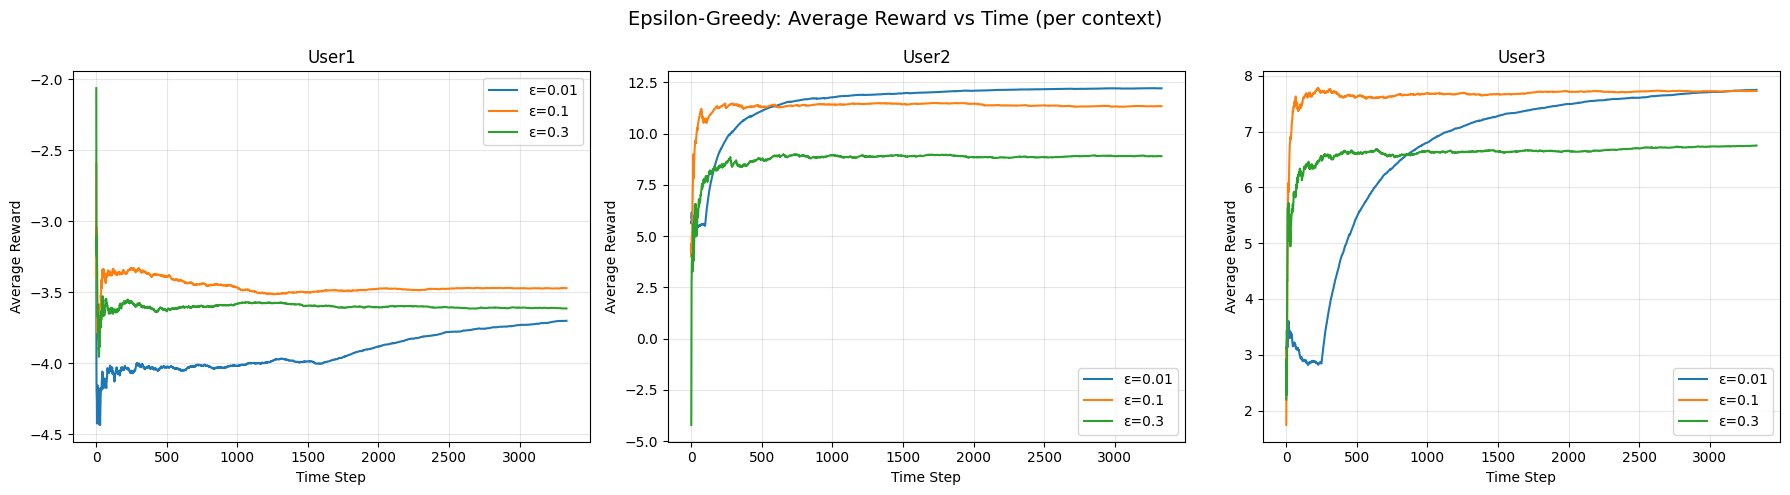

In [17]:
# Plot 1: Average Reward vs Time for Epsilon-Greedy (per context)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Epsilon-Greedy: Average Reward vs Time (per context)", fontsize=14)

for idx, c in enumerate(range(n_contexts)):
    ax = axes[idx]
    for eps in epsilon_values:
        r = eg_results[eps]["rewards"][c]
        avg_r = running_avg(r)
        ax.plot(avg_r, label=f"ε={eps}")
    ax.set_title(f"{context_names[c]}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

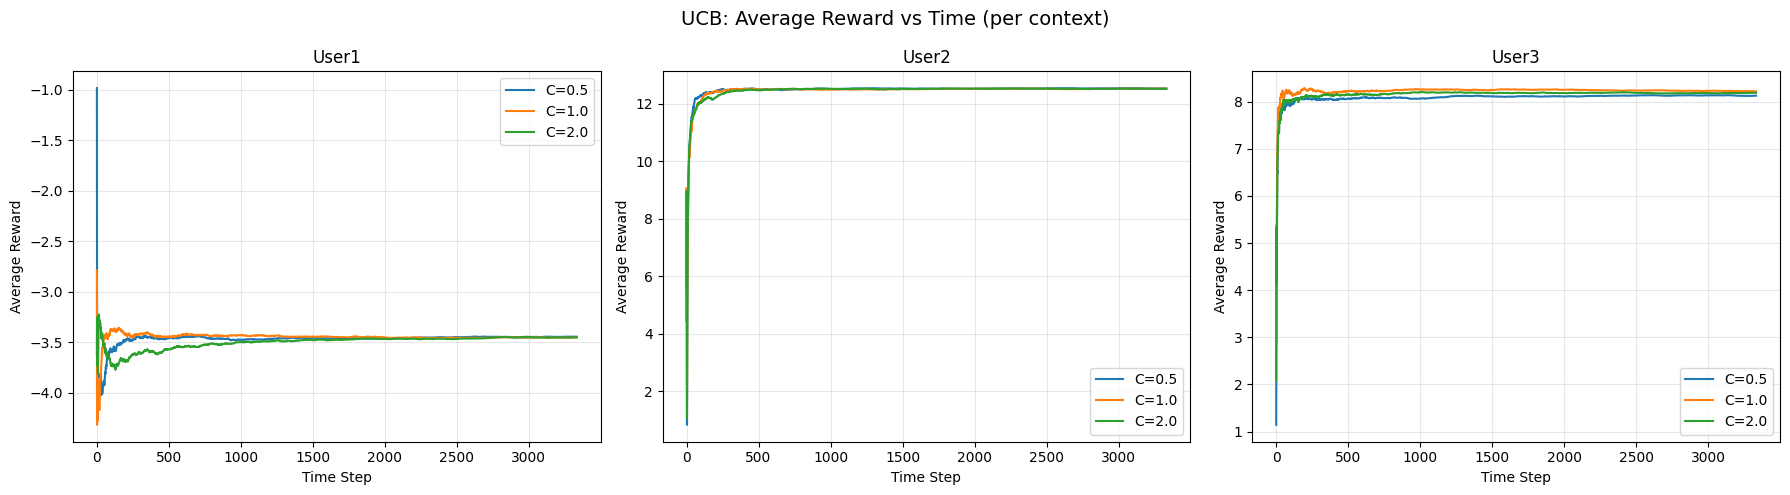

In [18]:
# Plot 2: Average Reward vs Time for UCB (per context)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UCB: Average Reward vs Time (per context)", fontsize=14)

for idx, c in enumerate(range(n_contexts)):
    ax = axes[idx]
    for C in C_values:
        r = ucb_results[C]["rewards"][c]
        avg_r = running_avg(r)
        ax.plot(avg_r, label=f"C={C}")
    ax.set_title(f"{context_names[c]}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

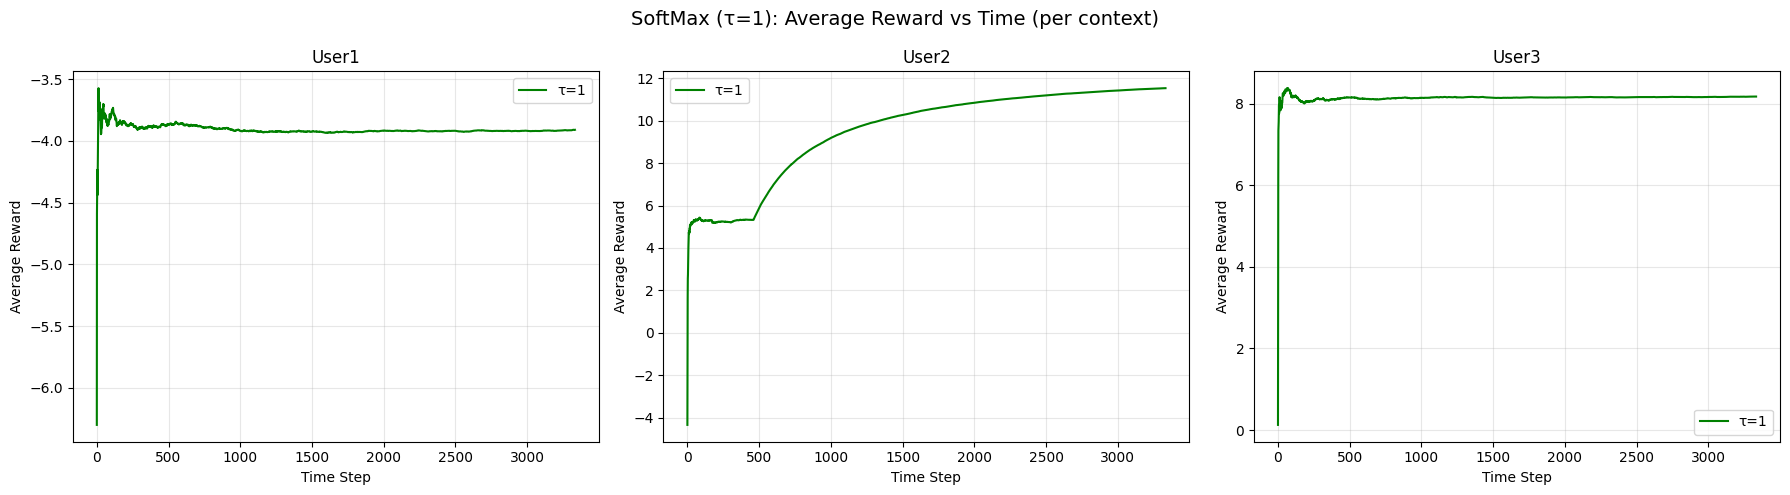

In [19]:
# Plot 3: SoftMax Average Reward vs Time (per context)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SoftMax (τ=1): Average Reward vs Time (per context)", fontsize=14)

for idx, c in enumerate(range(n_contexts)):
    ax = axes[idx]
    r = rewards_sm[c]
    avg_r = running_avg(r)
    ax.plot(avg_r, color="green", label="τ=1")
    ax.set_title(f"{context_names[c]}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best epsilon: 0.01
best C: 1.0


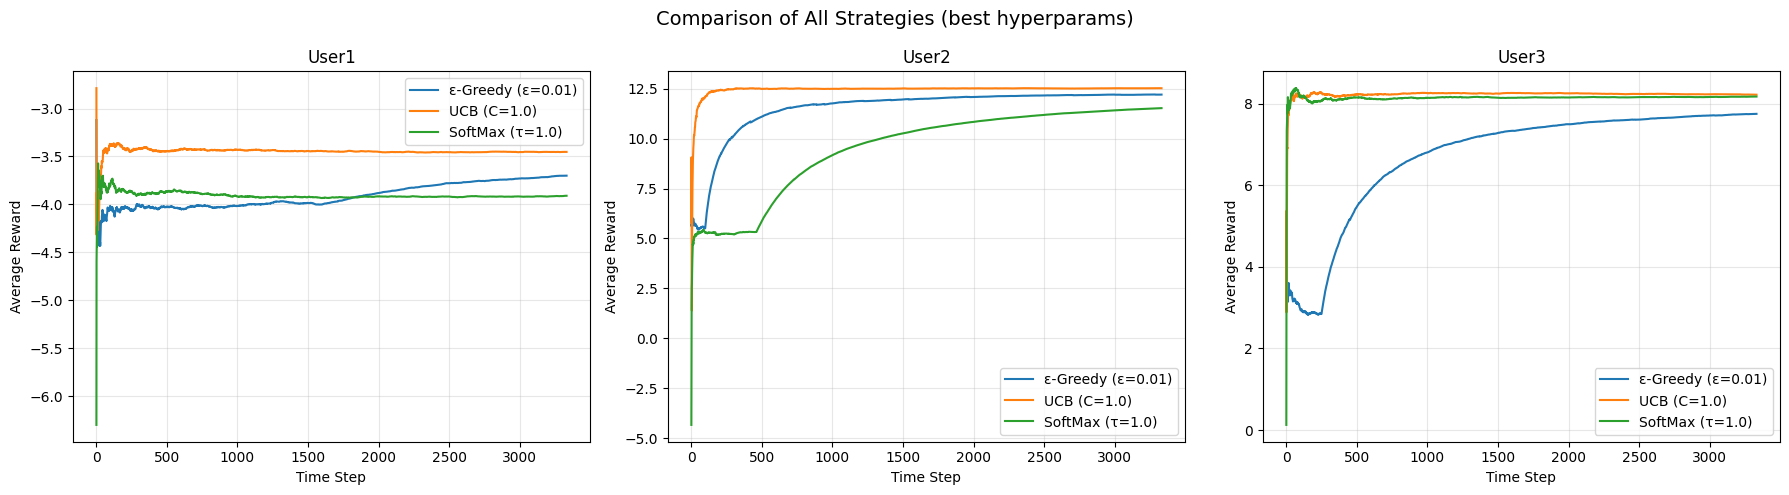

In [20]:
# Plot 4: comparing all 3 strategies (using best hyperparams)
# picking the best epsilon and C based on final avg reward
best_eps = max(epsilon_values, key=lambda e: np.mean([np.mean(eg_results[e]["rewards"][c]) for c in range(n_contexts)]))
best_C = max(C_values, key=lambda c_val: np.mean([np.mean(ucb_results[c_val]["rewards"][c]) for c in range(n_contexts)]))

print(f"best epsilon: {best_eps}")
print(f"best C: {best_C}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparison of All Strategies (best hyperparams)", fontsize=14)

for idx, c in enumerate(range(n_contexts)):
    ax = axes[idx]
    
    # epsilon greedy
    r_eg = eg_results[best_eps]["rewards"][c]
    ax.plot(running_avg(r_eg), label=f"ε-Greedy (ε={best_eps})")
    
    # ucb
    r_ucb = ucb_results[best_C]["rewards"][c]
    ax.plot(running_avg(r_ucb), label=f"UCB (C={best_C})")
    
    # softmax
    r_sm = rewards_sm[c]
    ax.plot(running_avg(r_sm), label=f"SoftMax (τ={tau})")
    
    ax.set_title(f"{context_names[c]}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Average Reward")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

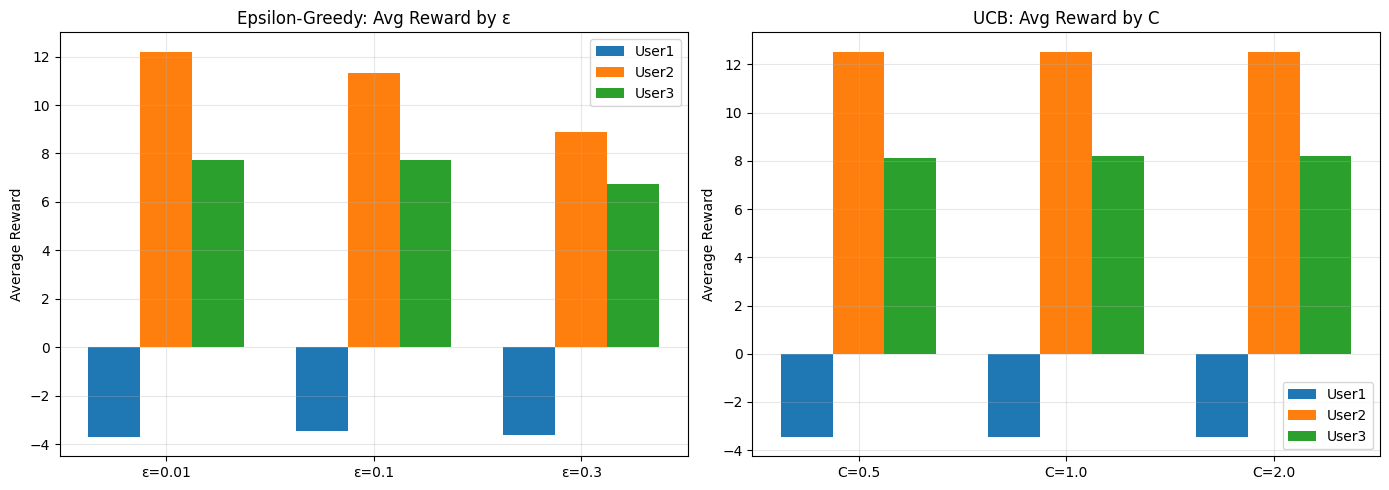

In [21]:
# Plot 5: hyperparameter comparison bar chart
# comparing final avg rewards for different epsilon values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# epsilon comparison
ax = axes[0]
x = np.arange(len(epsilon_values))
width = 0.25
for c in range(n_contexts):
    avg_rewards = [np.mean(eg_results[eps]["rewards"][c]) for eps in epsilon_values]
    ax.bar(x + c*width, avg_rewards, width, label=context_names[c])
ax.set_xticks(x + width)
ax.set_xticklabels([f"ε={e}" for e in epsilon_values])
ax.set_ylabel("Average Reward")
ax.set_title("Epsilon-Greedy: Avg Reward by ε")
ax.legend()
ax.grid(True, alpha=0.3)

# C comparison
ax = axes[1]
x = np.arange(len(C_values))
for c in range(n_contexts):
    avg_rewards = [np.mean(ucb_results[C]["rewards"][c]) for C in C_values]
    ax.bar(x + c*width, avg_rewards, width, label=context_names[c])
ax.set_xticks(x + width)
ax.set_xticklabels([f"C={c}" for c in C_values])
ax.set_ylabel("Average Reward")
ax.set_title("UCB: Avg Reward by C")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.4 Recommendation Engine

Putting it all together:  
1. Classify user -> get context  
2. Use bandit policy to pick best news category  
3. Sample a random article from that category

In [22]:
# using the best epsilon-greedy result for the recommendation engine
# since it gave pretty good results 
best_Q = eg_results[best_eps]["Q"]

# getting the optimal arm per context
optimal_arms = {}
for c in range(n_contexts):
    best_arm = np.argmax(best_Q[c])
    optimal_arms[c] = best_arm
    print(f"{context_names[c]} -> best category: {news_categories[best_arm]} (Q={best_Q[c][best_arm]:.4f})")

User1 -> best category: TECH (Q=-3.4168)
User2 -> best category: EDUCATION (Q=12.5418)
User3 -> best category: TECH (Q=8.1990)


In [23]:
def recommend_article(user_row, policy_Q):
    # step 1: classify user to get context
    user_df = pd.DataFrame([user_row])
    context = predict_user_context(user_df)[0]
    
    # step 2: use bandit policy to pick best news category
    best_arm = np.argmax(policy_Q[context])
    category = news_categories[best_arm]
    
    # step 3: sample random article from that category
    category_articles = news_articles[news_articles["category"] == category]
    if len(category_articles) == 0:
        # fallback if no exact match
        category_articles = news_articles
    
    sampled_article = category_articles.sample(1).iloc[0]
    
    return {
        "user_context": context_names[context],
        "recommended_category": category,
        "article_headline": sampled_article["headline"],
        "article_link": sampled_article["link"]
    }

print("recommendation function ready")

recommendation function ready


In [24]:
# testing the recommendation engine on first 10 test users
print("=" * 80)
print("RECOMMENDATION ENGINE OUTPUT")
print("=" * 80)

feature_cols_test = [c for c in test_users.columns if c != "user_id"]

for i in range(10):
    user_row = test_users.iloc[i][feature_cols_test]
    rec = recommend_article(user_row, best_Q)
    print(f"\nUser {i+1} (ID: {test_users.iloc[i]['user_id']}):")
    print(f"  Context: {rec['user_context']}")
    print(f"  Recommended Category: {rec['recommended_category']}")
    print(f"  Article: {rec['article_headline'][:80]}...")

RECOMMENDATION ENGINE OUTPUT

User 1 (ID: U4058):
  Context: User3
  Recommended Category: TECH
  Article: 23andMe Gets Patent For Baby Trait Predictions Calculator, But Says It Won't Be ...

User 2 (ID: U1118):
  Context: User1
  Recommended Category: TECH
  Article: Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000...

User 3 (ID: U6555):
  Context: User1
  Recommended Category: TECH
  Article: Google's Self-Driving Cars Will Honk At You If You're Not Paying Attention...

User 4 (ID: U9170):
  Context: User1
  Recommended Category: TECH
  Article: Tinder Now Lets You 'Swipe Up' On People You REALLY Like...

User 5 (ID: U3348):
  Context: User1
  Recommended Category: TECH
  Article: Huawei Partner Offered To Illegally Sell HP Computers To Iran...

User 6 (ID: U2244):
  Context: User3
  Recommended Category: TECH
  Article: The Prosecution of Aaron Swartz: A Reply to Orin Kerr...

User 7 (ID: U3022):
  Context: User3
  Recommended Category: TECH
  Article: FlyingBu

In [25]:
# running recommendations for all test users and showing distribution
all_recommendations = []
for i in range(len(test_users)):
    user_row = test_users.iloc[i][feature_cols_test]
    rec = recommend_article(user_row, best_Q)
    all_recommendations.append(rec)

rec_df = pd.DataFrame(all_recommendations)
print("recommendation distribution:")
print(rec_df["recommended_category"].value_counts())
print("\nby context:")
print(rec_df.groupby("user_context")["recommended_category"].value_counts())

recommendation distribution:
recommended_category
TECH         1334
EDUCATION     666
Name: count, dtype: int64

by context:
user_context  recommended_category
User1         TECH                    609
User2         EDUCATION               666
User3         TECH                    725
Name: count, dtype: int64


## Final Observations

### Strategy Comparison

- **Epsilon-Greedy**: This was a pretty straightforward algorithm to implement. I noticed that with a really small epsilon like 0.01, it stopped exploring pretty quickly and stuck to the best arm it found. But when I tried a bigger epsilon (0.3), it kept checking other options which was good for finding better arms, but it also wasted a lot of pulls on bad ones.

- **UCB**: I liked UCB because it figures out the exploration/exploitation balance on its own. With C=0.5, it was a bit hesitant to explore, but C=2.0 made it try out way more arms before settling down. The cool thing is that unlike epsilon-greedy, I didn't have to manually tune the exploration rate since it naturally decreases as it learns.

- **SoftMax (τ=1)**: This approach felt a bit more nuanced. Instead of just picking randomly some % of the time, it picks based on how good the arms look. With τ=1, it wasn't too crazy about exploring but also didn't just greedily pick the best one every time. It seemed to smoothly shift towards the best arm as it gathered more data.

### Hyperparameter Effects

- For epsilon-greedy, a tiny ε helped get better final scores, but if it got unlucky at the start, it could get stuck on a mediocre arm. A huge ε solved that but meant fewer rewards overall.
- For UCB, the C value basically decides how "curious" the algorithm is. A bigger C resulted in more exploration. I read that theoretically C should be around 1.414, but tweaking it definitely changed how fast it learned.

### Overall

All three algorithms eventually figured out which news category each user liked best. UCB seemed the most consistent to me because it stops exploring so much once it's confident, whereas epsilon-greedy keeps making those random choices even after 10,000 steps, which feels a bit inefficient.